# Sequential ViDA: Messidor → IDRiD → APTOS (RETFound-DINOv2)

Protocol:
1. Load RETFound pretrained weights
2. Evaluate baseline on source domain (Messidor-2)
3. Adapt to target domain (IDRiD) - adaptation mode
4. Adapt to target domain (APTOS) - adaptation mode
5. Evaluate on ALL previous domains - TEST mode

This tests if Messidor as source provides useful initialization.

In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
import sys, os; sys.path.insert(0, os.getcwd())
import os, sys
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

from src.config import load_config

In [3]:
config = load_config('configs/method/sequential/vida/messidor_idrid_aptos.yaml')

print('Protocol: Sequential ViDA')
print(f'Source: {config.sequential.source_dataset.name}')
print(f'Targets: {[t.name for t in config.sequential.target_datasets]}')
print('Method:', config.ctta.method)
print('Output:', config.output_dir)

# RETFound weights are gated behind HuggingFace; require a token.
if config.model.name == 'retfound' and not os.environ.get('HF_TOKEN'):
    import getpass
    token = getpass.getpass('Enter your HuggingFace token (hf_...): ')
    os.environ['HF_TOKEN'] = token
    print('HF_TOKEN set')
elif config.model.name != 'retfound':
    print('No HF token needed (VisionFM / Google Drive)')

Protocol: Sequential ViDA
Source: messidor2
Targets: ['idrid', 'aptos2019']
Method: cotta
Output: ./outputs/sequential_vida/messidor_idrid_aptos/
HF_TOKEN set


In [4]:
from src.evaluation.runner import SequentialCTTARunner

runner = SequentialCTTARunner(config)
results = runner.run()

2026-08-05 21:04:31,306 - src.evaluation.runner.sequential - INFO - Starting sequential CTTA: messidor2 -> idrid -> aptos2019
2026-08-05 21:04:36,361 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/YukunZhou/RETFound_dinov2_meh/resolve/main/RETFound_dinov2_meh.pth "HTTP/1.1 302 Found"
2026-08-05 21:04:36,562 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/YukunZhou/RETFound_dinov2_meh/xet-read-token/6dff4c76632983267a6ae3000f7852b1f8667d9c "HTTP/1.1 200 OK"


RETFound_dinov2_meh.pth:   0%|          | 0.00/1.61G [00:00<?, ?B/s]

2026-08-05 21:04:46,747 - src.models.retfound - INFO - Extracted state_dict from DINOv2 'teacher' key
2026-08-05 21:04:46,749 - src.models.retfound - INFO - Stripped 'backbone.' prefix from 359 state dict keys
2026-08-05 21:04:46,750 - src.models.retfound - INFO - RETFound checkpoint cached in CPU RAM
2026-08-05 21:04:46,927 - src.models.retfound - INFO - Feature normalization ENABLED in forward() (required for prototype classifier)
2026-08-05 21:04:47,661 - src.evaluation.runner.base - INFO - Loaded RETFound pretrained weights
2026-08-05 21:06:16,023 - src.evaluation.runner.base - INFO - Prototype weights scaled by T=100.0
2026-08-05 21:06:16,027 - src.evaluation.runner.base - INFO - Prototype classifier initialized from 1395 training samples (5 classes, 1024-dim features, T=100.0)
2026-08-05 21:06:17,423 - src.evaluation.runner.sequential - INFO - Evaluating baseline on source domain: messidor2
2026-08-05 21:06:39,766 - src.evaluation.runner.sequential - INFO - Baseline QWK on messid

Adapting to messidor2:   0%|          | 0/22 [00:00<?, ?it/s]

2026-08-05 21:07:00,250 - src.evaluation.runner.sequential - INFO -   Adapt step 0: loss=0.0013, kl=0.0013, conf_samples=-1, teacher_max_prob=-1.0000


...

Adapting to aptos2019:  96%|█████████▌| 22/23 [06:47<00:18, 18.43s/it, acc=0.3750, adaptations=22]

2026-08-05 21:24:13,273 - src.evaluation.runner.sequential - INFO -   Adapt step 22: loss=0.0043, kl=0.0043, conf_samples=-1, teacher_max_prob=-1.0000


Adapting to aptos2019: 100%|██████████| 23/23 [07:04<00:00, 18.47s/it, acc=0.2143, adaptations=23]

2026-08-05 21:24:14,282 - src.evaluation.runner.sequential - INFO - Evaluating after adaptation on aptos2019


2026-08-05 21:24:43,798 - src.evaluation.runner.sequential - INFO - Post-adaptation QWK: 0.7167
2026-08-05 21:24:43,801 - src.evaluation.runner.sequential - INFO - Adaptations: 23/23
2026-08-05 21:24:43,943 - src.evaluation.runner.sequential - INFO - 
Evaluating on all 3 seen domains after adapting to aptos2019
2026-08-05 21:24:43,945 - src.evaluation.runner.sequential - INFO -   Test-only evaluation on messidor2 (no adaptation)
2026-08-05 21:25:09,616 - src.evaluation.runner.sequential - INFO -   QWK on messidor2: 0.7231
2026-08-05 21:25:09,618 - src.evaluation.runner.sequential - INFO -   Test-only evaluation on idrid (no adaptation)
2026-08-05 21:25:20,572 - src.evaluation.runner.sequential - INFO -   QWK on idrid: 0.5911
2026-08-05 21:25:50,301 - src.evaluation.runner.sequential - INFO -   QWK on aptos2019: 0.7167
2026-08-05 21:25:50,304 - src.evaluation.runner.sequential - INFO - 
2026-08-05 21:25:50,305 - src.evaluation.runner.sequential - INFO - Sequential CTTA Complete - Summar

=============== Sequential CTTA Results (ViDA DINOv2) ================

Source domain: messidor2
  Baseline QWK:           0.7529
  Baseline Overall Acc:   65.90%

Target domains: idrid, aptos2019

----------------------------------------------------------------------
After adapting to source messidor2 (22/22 batches):
  QWK:                  0.7225  (delta: -0.0304)
  Overall Acc:          59.89% (delta: -6.02pp)

----------------------------------------------------------------------
After adapting to idrid (7/7 batches):
  Post-adaptation QWK on idrid: 0.6059
  Post-adaptation Acc on idrid: 44.66%
  Test on messidor2:
    QWK: 0.7637  (delta vs baseline: +0.0108)
    Acc: 61.03% (delta vs baseline: -4.87pp)

----------------------------------------------------------------------
After adapting to aptos2019 (23/23 batches):
  Post-adaptation QWK on aptos2019: 0.7167
  Post-adaptation Acc on aptos2019: 36.89%
  Test on messidor2:
    QWK: 0.7231  (delta vs baseline: -0.0298)
    Acc: 60

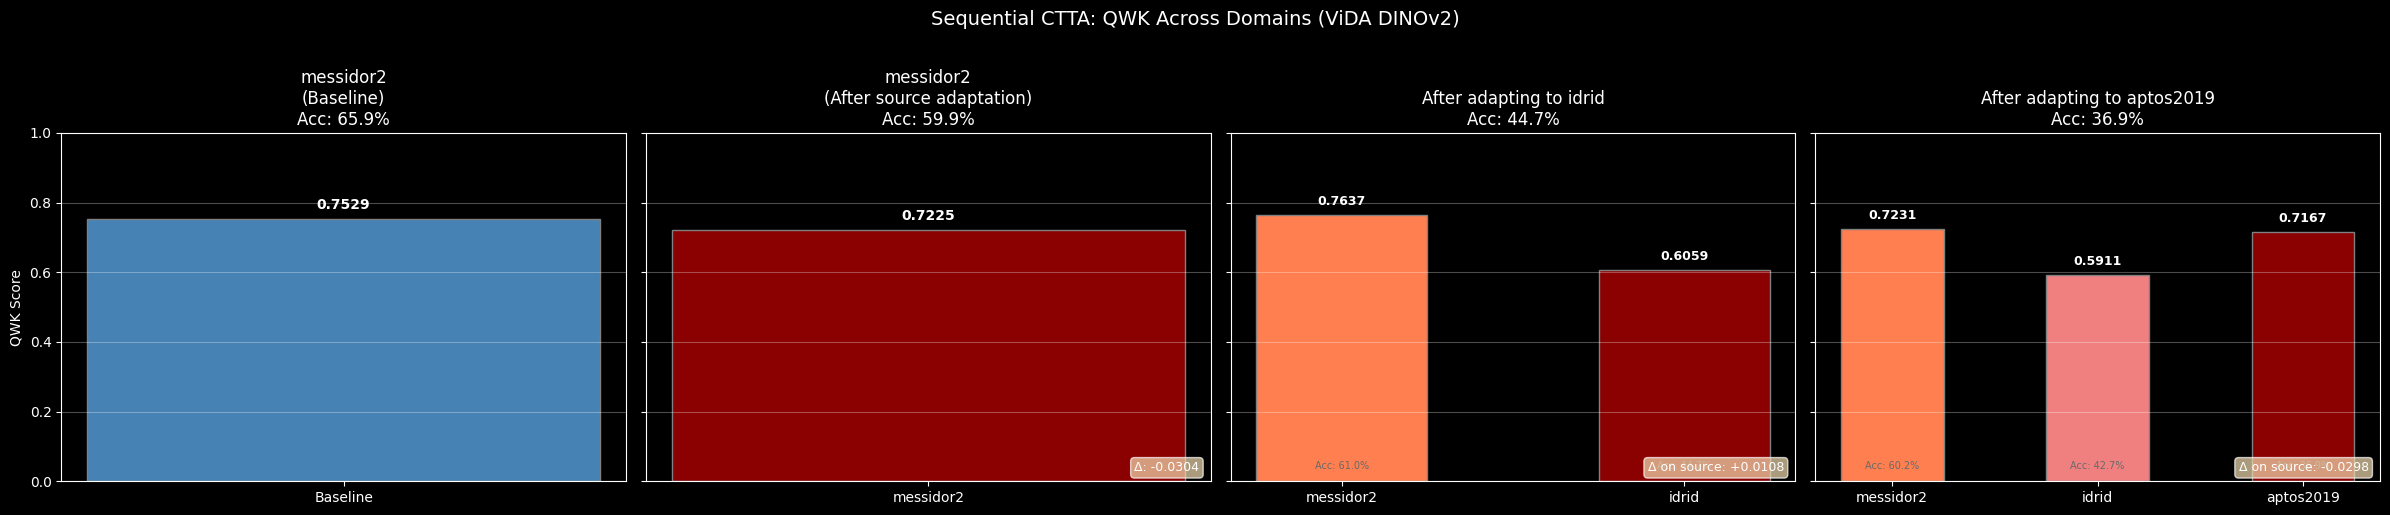

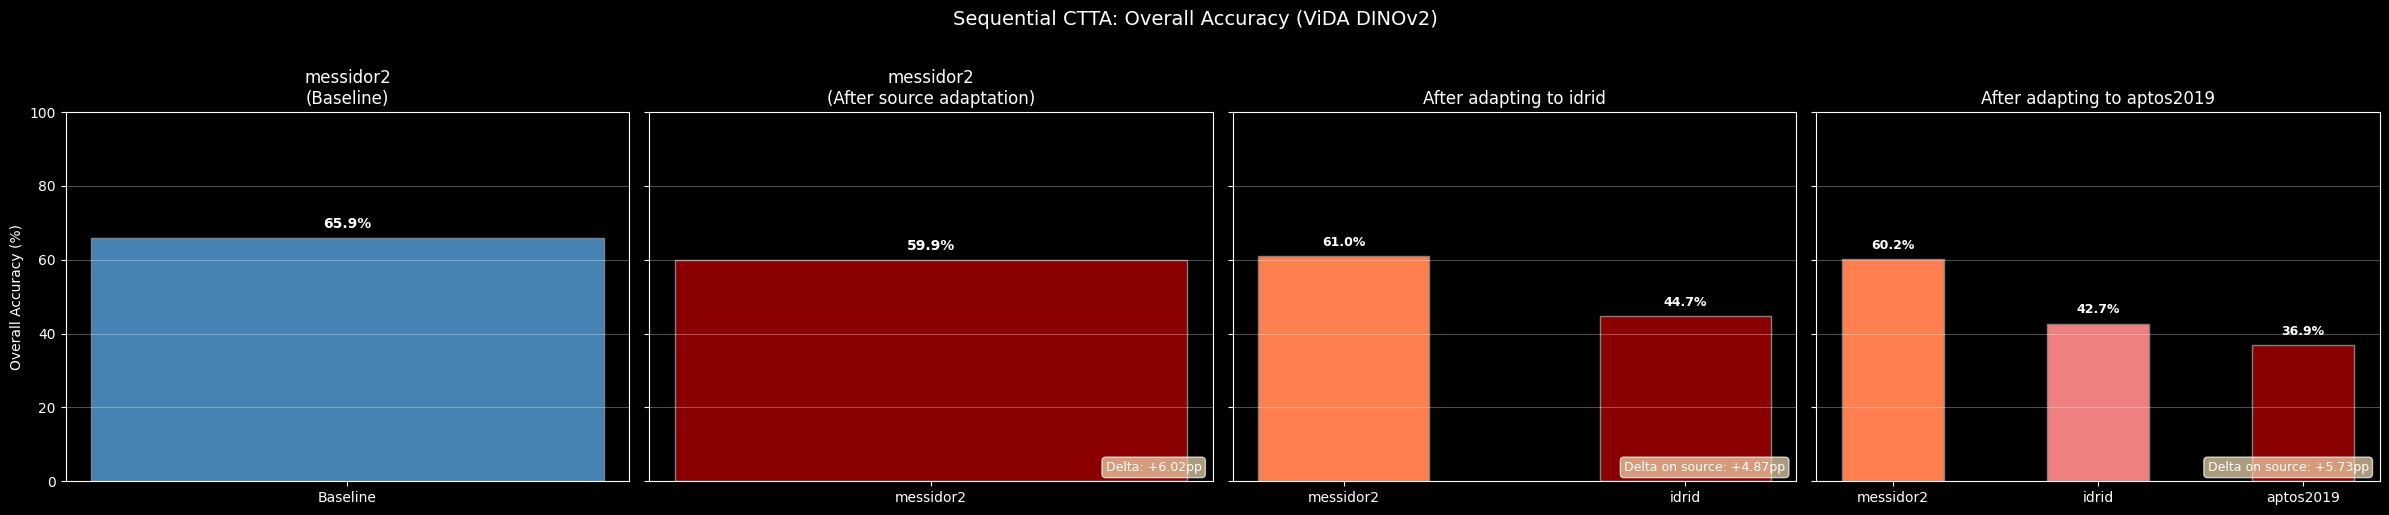

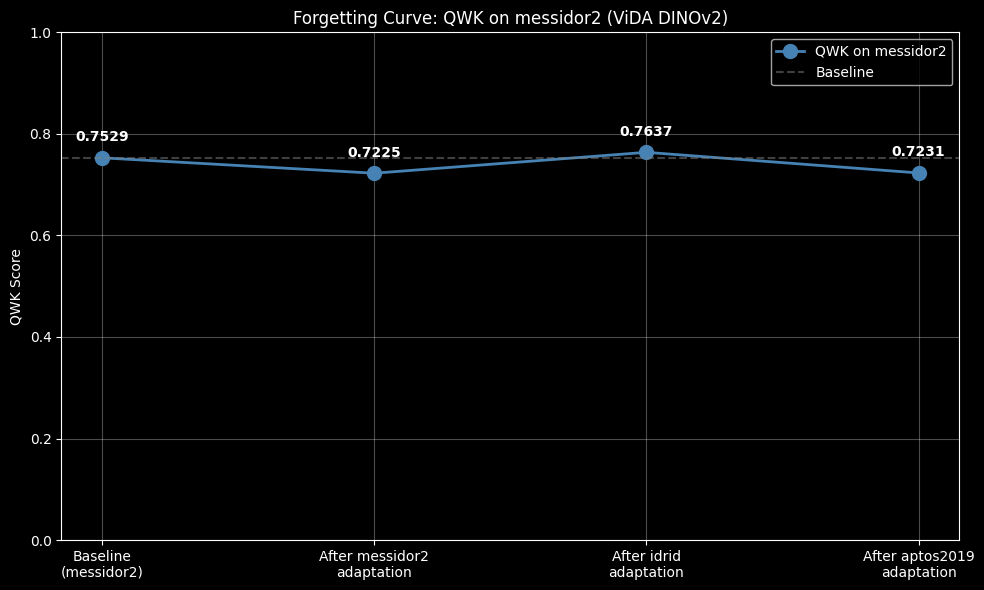

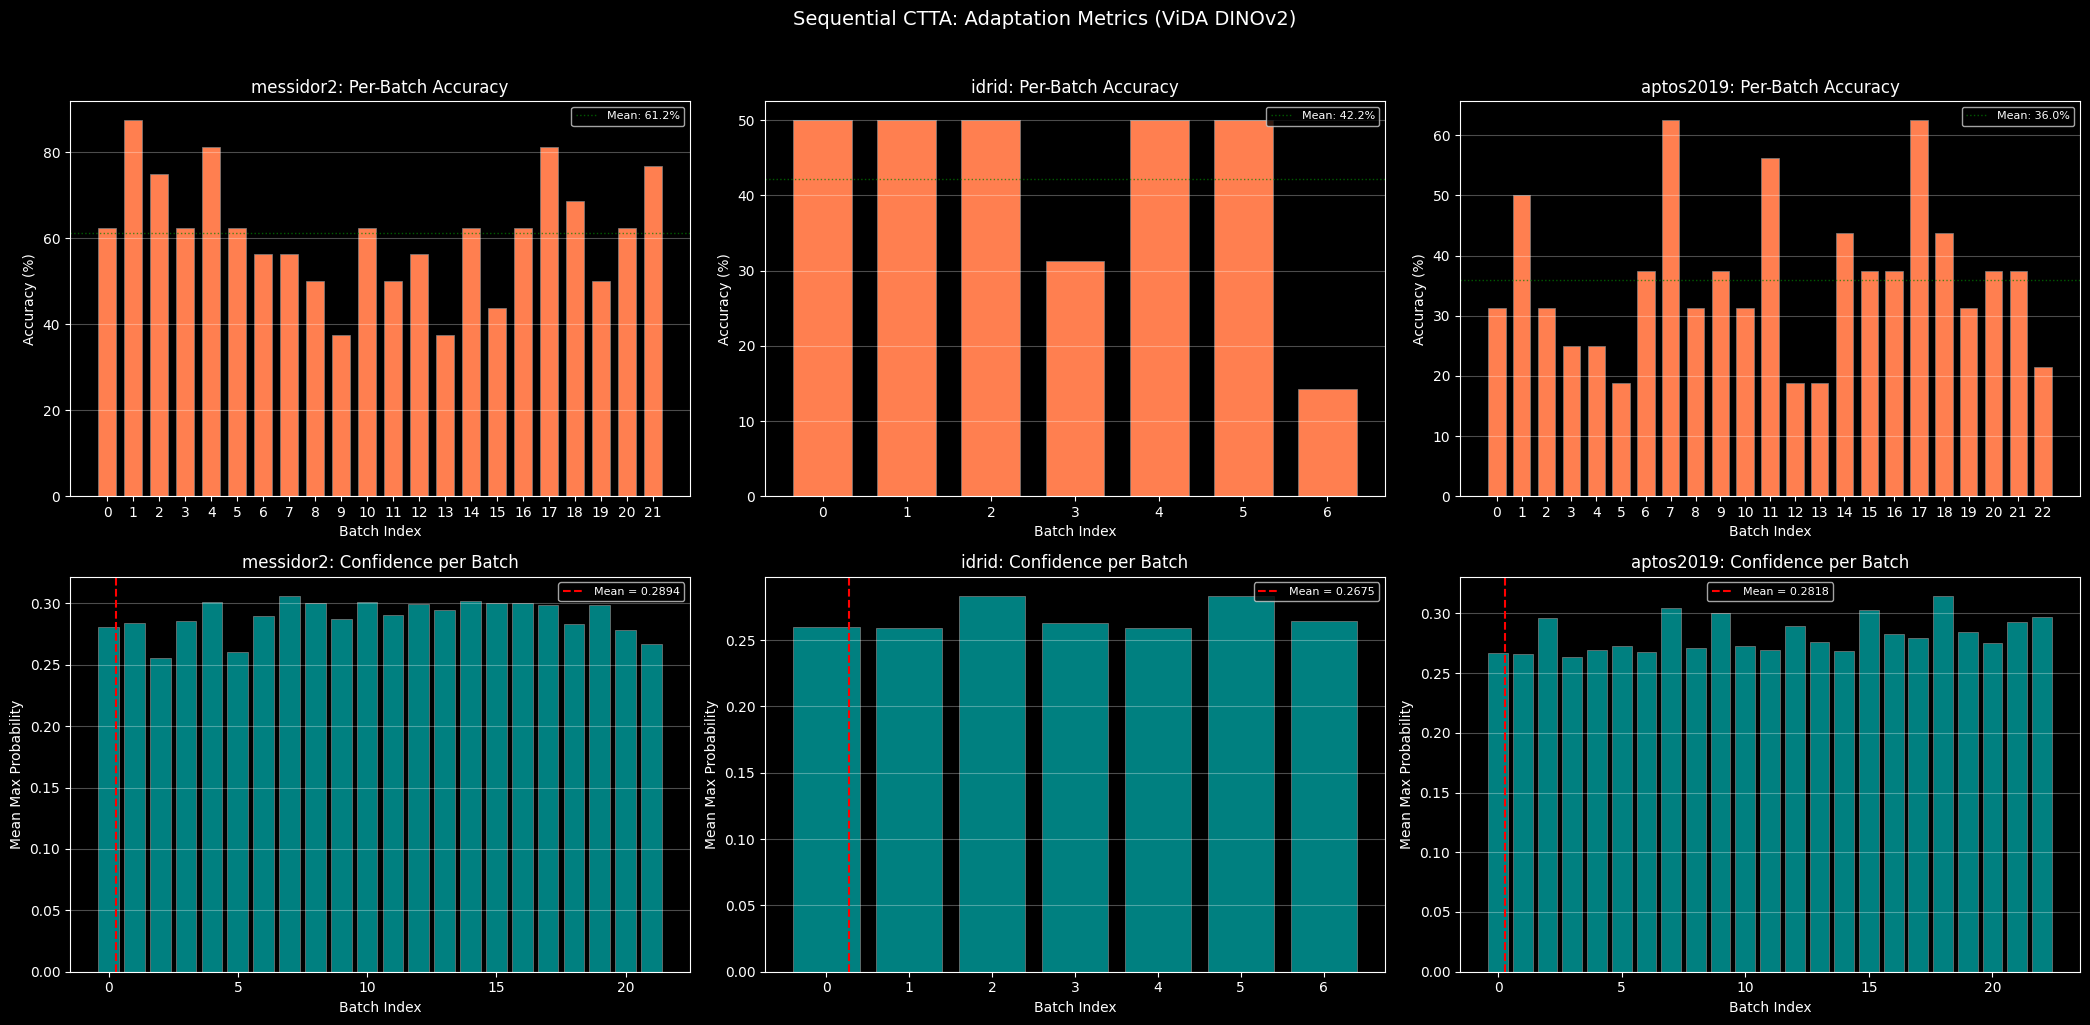

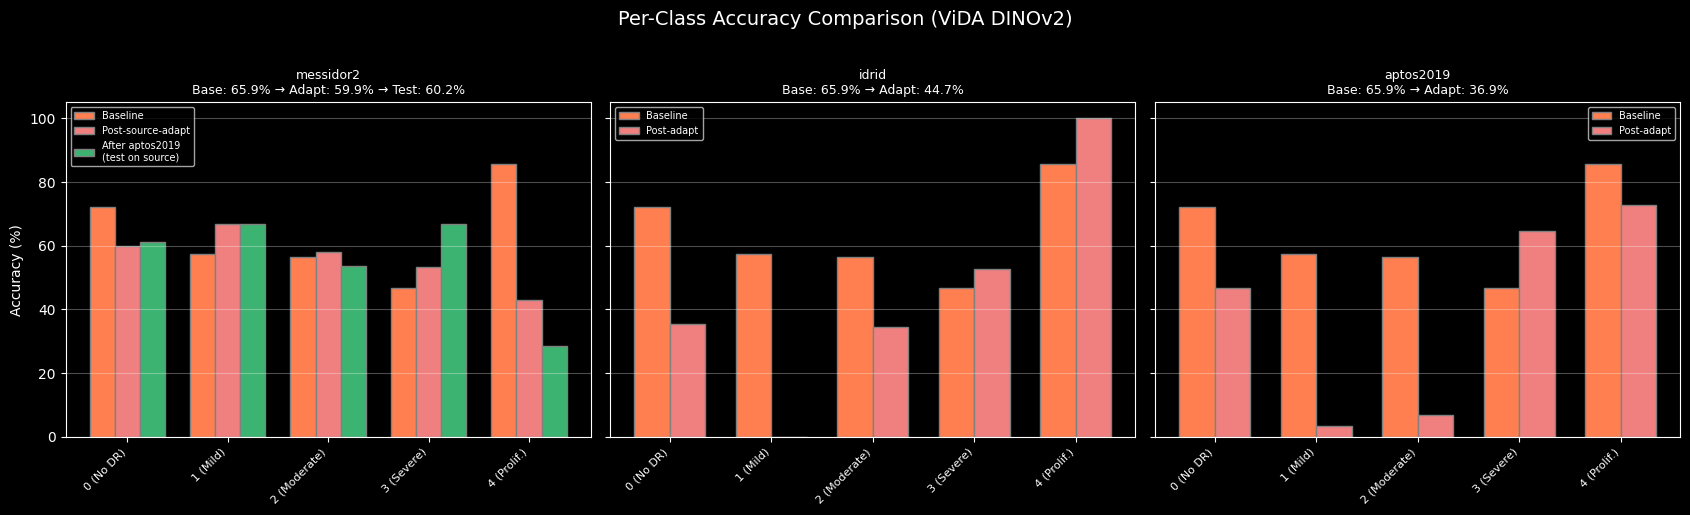

In [5]:
from pathlib import Path
from src.viz import (
    load_standalone_results,
    plot_sequential_qwk_comparison,
    plot_sequential_overall_accuracy,
    plot_sequential_forgetting,
    plot_sequential_adaptation_comparison,
    plot_sequential_per_class_accuracy,
    print_sequential_summary,
)

plots_dir = Path(config.output_dir) / 'plots'
plots_dir.mkdir(exist_ok=True)

method_name = 'ViDA DINOv2' if config.model.name == 'retfound' else 'ViDA VisionFM'

print_sequential_summary(results, method_name=method_name)
plot_sequential_qwk_comparison(results, plots_dir, method_name=method_name)
plot_sequential_overall_accuracy(results, plots_dir, method_name=method_name)
plot_sequential_forgetting(results, plots_dir, method_name=method_name)
plot_sequential_adaptation_comparison(results, plots_dir, method_name=method_name)
plot_sequential_per_class_accuracy(results, plots_dir, method_name=method_name)